In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import statsmodels.api as sm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
# Data extraction from NetCDF file

ds = xr.open_dataset("C:/Users/HP/Downloads/Budget terms paper/mon_india_IMD_rainfall.nc")
print(ds)
tp = ds['RAINFALL'][:,:,:].values
lat = ds['LATITUDE'][:].values
lon = ds['LONGITUDE'][:].values
time = pd.to_datetime(ds['TIME'].values)

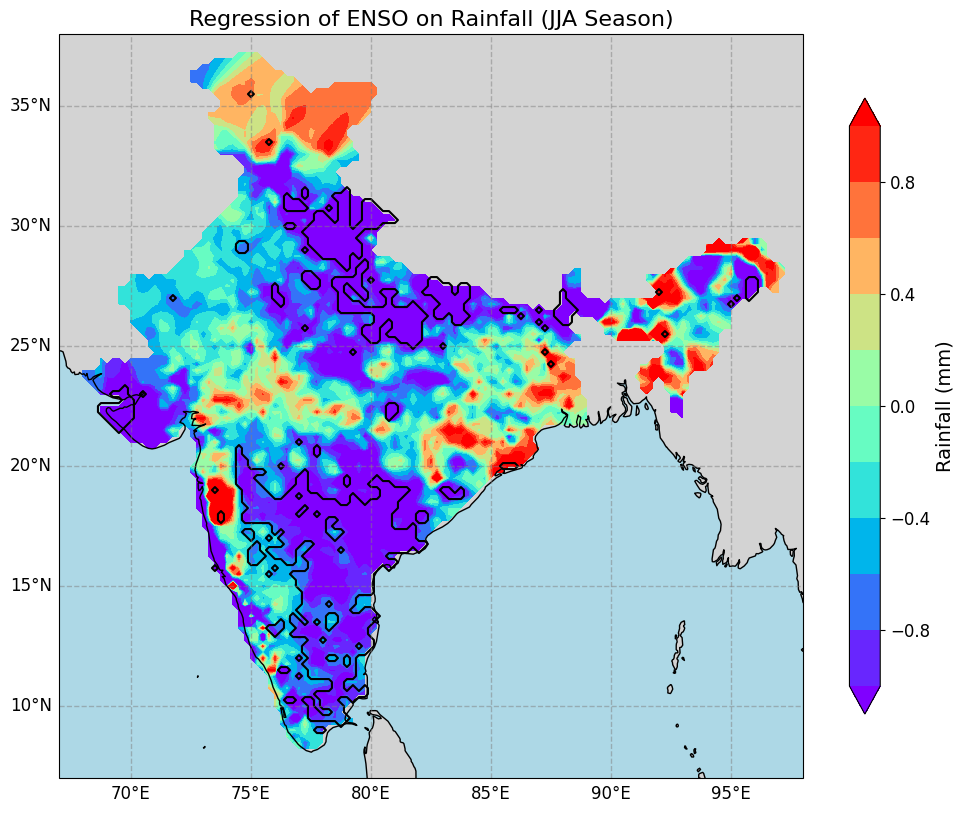

In [ ]:
# Sea Surface Temperature monthly Climate Indices of Indian Ocean Dipole (DMI), 
# El Nino Southern Oscillations (Nino3.4), and Indian Ocean Tripole (TMI) extracted from Excel file
seasonal_indices = pd.read_excel("C:/Users/HP/Downloads/Budget terms paper/climate_indices_calculation.xlsx")
iod = seasonal_indices['DMI_30']
tmi = seasonal_indices['TMI_30']
enso = seasonal_indices['ENSO_30']

# Convert each month's integer to a representative seasonal index:  
year, month, _ = time.year, time.month, time.day
month = month.values
month[(month == 12) | (month == 1) | (month == 2)] = 1   # DJF
month[(month == 3) | (month == 5)] = 4                    # MAM
month[(month == 6) | (month == 8)] = 7                    # JJA
month[(month == 11) | (month == 9)] = 10                  # SON

# Find array indices corresponding to each season
d1 = np.where(month == 1)[0]
m1 = np.where(month == 4)[0]
j1 = np.where(month == 7)[0]
s1 = np.where(month == 10)[0]

# Extract climate mode indices for particular season (used in regression)
ensod = enso[j1]
iodd = iod[j1]
tmid = tmi[j1]

# Initialize arrays for regression coefficients and p-values
sa, so = len(lat), len(lon)
reg_iod_tp = np.zeros((so, sa))
reg_tmi_tp = np.zeros((so, sa))
reg_enso_tp = np.zeros((so, sa))
pval_iod_tp = np.zeros((so, sa))
pval_tmi_tp = np.zeros((so, sa))
pval_enso_tp = np.zeros((so, sa))

# Loop over all longitude and latitude points to perform regression at each grid
for lo in range(so):
    for la in range(sa):
        # Extract rainfall values for the current grid point during JJA season
        tp_seasonal = tp[j1, la, lo]

         # Check for missing data (NaNs) and if missing data exists, assign NaN to regression results
        if np.isnan(tp_seasonal).any():
            reg_iod_tp[lo, la] = np.nan
            reg_tmi_tp[lo, la] = np.nan
            reg_enso_tp[lo, la] = np.nan
            pval_iod_tp[lo, la] = np.nan
            pval_tmi_tp[lo, la] = np.nan
            pval_enso_tp[lo, la] = np.nan
        else:
            # Prepare the design matrix with climate indices (IOD, TMI, ENSO)
            X = np.column_stack((iodd, tmid, ensod))
            X = sm.add_constant(X)        # Add intercept term
           
            # Fit Ordinary Least Squares (OLS) regression
            reg = sm.OLS(tp_seasonal, X, missing='drop').fit()

            # Store regression coefficients for each climate mode
            reg_iod_tp[lo, la] = reg.params[1]
            reg_tmi_tp[lo, la] = reg.params[2]
            reg_enso_tp[lo, la] = reg.params[3]

            # Store corresponding p-values to assess statistical significance
            pval_iod_tp[lo, la] = reg.pvalues[1]
            pval_tmi_tp[lo, la] = reg.pvalues[2]
            pval_enso_tp[lo, la] = reg.pvalues[3]

#Significance Mask and Cartopy Plotting of Regression
# Define significance level for regression coefficients
alpha = 0.05
mask_enso_tp_significant = (pval_enso_tp < alpha)

fig = plt.figure(figsize=(12,10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent for India region
ax.set_extent([67, 98, 7, 38], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Create grid
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Contour plot of regression coefficient
bounds = np.arange(-1, 1.2, 0.2)
cf = ax.contourf(lon_grid, lat_grid, reg_enso_tp.T, levels=bounds, cmap='rainbow', extend='both', transform=ccrs.PlateCarree())

# Overlay significance contour
ax.contour(lon_grid, lat_grid, mask_enso_tp_significant.T.astype(int),
           levels=[0.5], colors='black', linewidths=1.5, transform=ccrs.PlateCarree())

# Add gridlines with lat/lon labels
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.xlabel_style = {'size':12}
gl.ylabel_style = {'size':12}

# Add colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Rainfall (mm)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.title('Regression of ENSO on Rainfall (JJA Season)', fontsize=16)
plt.show()